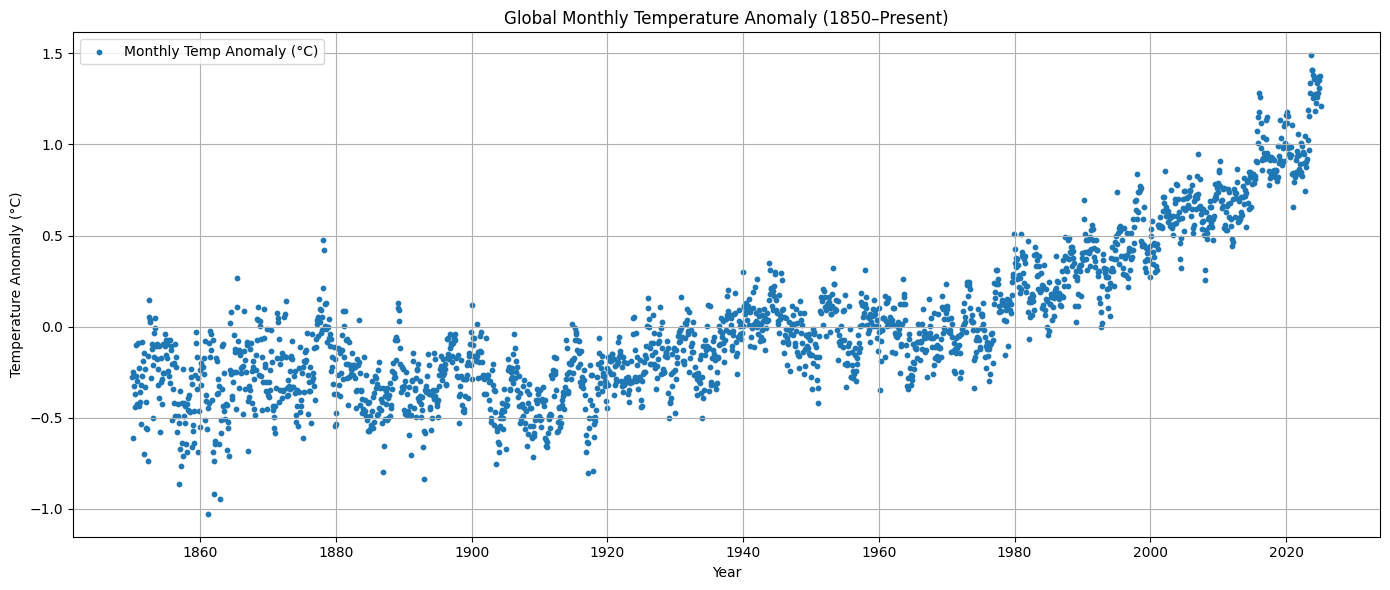

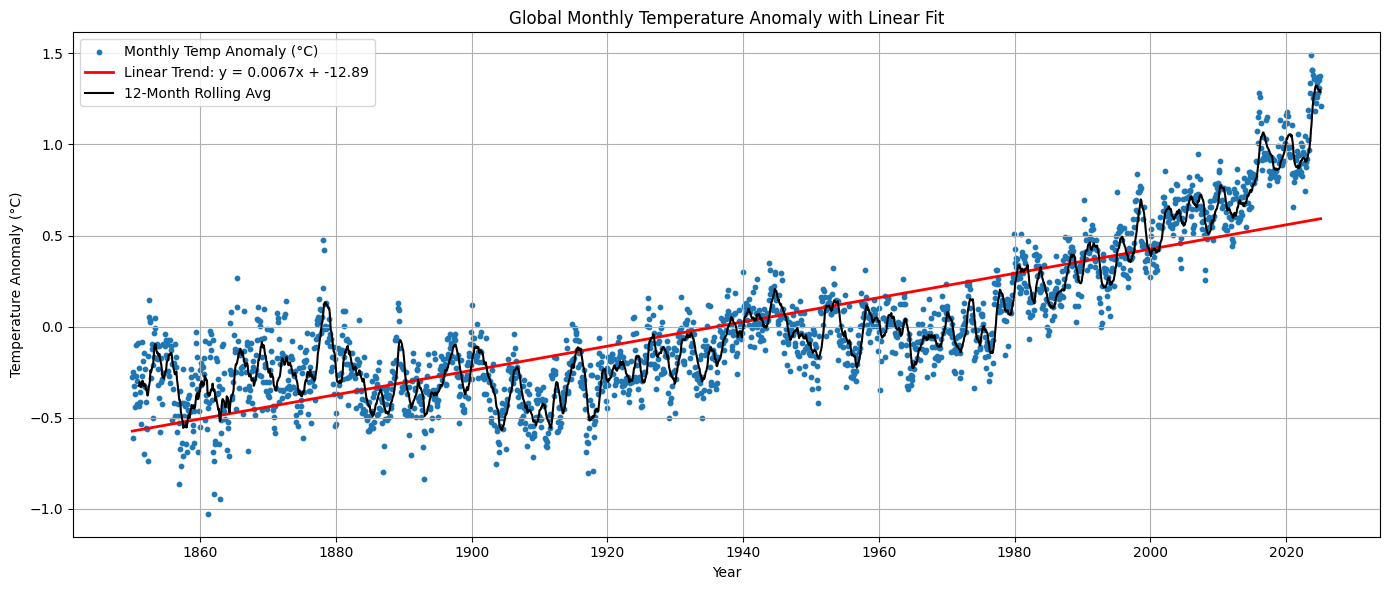

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# data
file_path = '/Users/darius/Downloads/Global_TAVG_monthly.txt'  

with open(file_path, 'r') as f:
    lines = f.readlines()

start_index = next(
    i for i, line in enumerate(lines)
    if line.strip().lstrip('%').strip().startswith('Year')
)

df = pd.read_csv(
    file_path,
    sep=r'\s+',
    engine='python',
    skiprows=start_index + 1,
    header=None,
    names=[
        'Year', 'Month', 'Monthly_Anomaly', 'Monthly_Unc',
        'Annual_Anomaly', 'Annual_Unc',
        'FiveYr_Anomaly', 'FiveYr_Unc',
        'TenYr_Anomaly', 'TenYr_Unc',
        'TwentyYr_Anomaly', 'TwentyYr_Unc'
    ]
)
# plotting the data
df = df.dropna(subset=['Monthly_Anomaly'])
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

plt.figure(figsize=(14, 6))
plt.scatter(df['Date'], df['Monthly_Anomaly'], s=10, label='Monthly Temp Anomaly (°C)')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.title('Global Monthly Temperature Anomaly (1850–Present)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# plotting the data with a linear fit and 12 month averages

df['YearFloat'] = df['Year'] + (df['Month'] - 1) / 12

coeffs = np.polyfit(df['YearFloat'], df['Monthly_Anomaly'], deg=1)
linear_fit = np.poly1d(coeffs)

trendline = linear_fit(df['YearFloat'])

plt.figure(figsize=(14, 6))
plt.scatter(df['Date'], df['Monthly_Anomaly'], s=10, label='Monthly Temp Anomaly (°C)')
plt.plot(df['Date'], trendline, color='red', linewidth=2, label=f'Linear Trend: y = {coeffs[0]:.4f}x + {coeffs[1]:.2f}')
df['Rolling_12mo'] = df['Monthly_Anomaly'].rolling(window=12).mean()
plt.plot(df['Date'], df['Rolling_12mo'], color='black', label='12-Month Rolling Avg', linewidth=1.5)
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.title('Global Monthly Temperature Anomaly with Linear Fit')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


